150


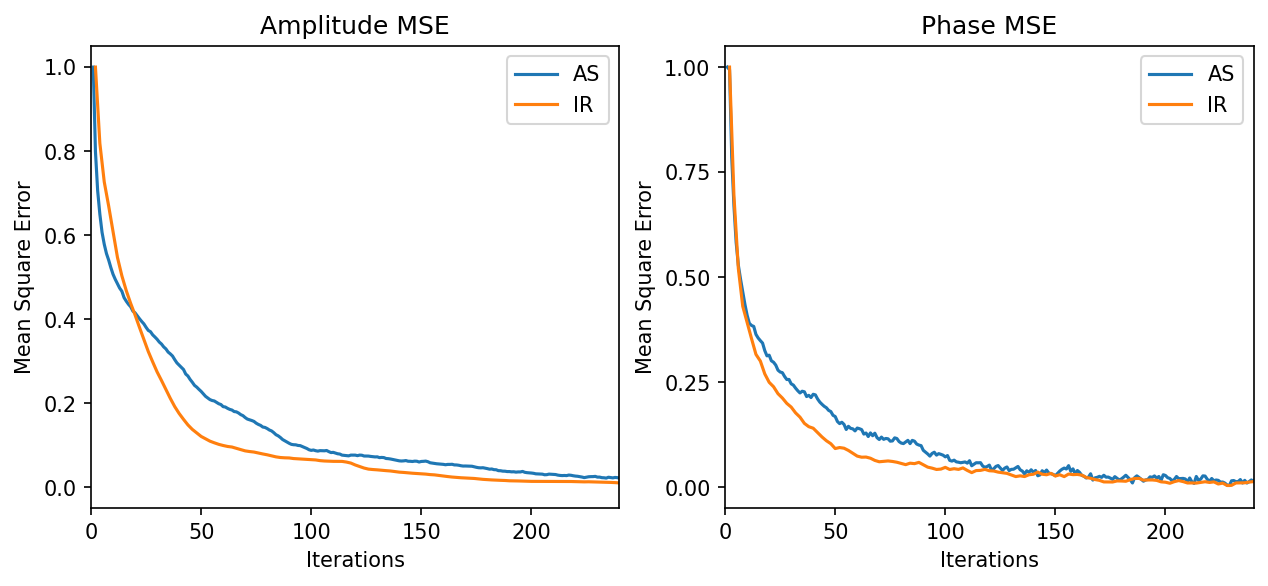

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

col_names=['Iterations','AS','IR']
df1=pd.read_excel('mseplots_amp_sbmir.xlsx')
if len(df1.columns)>3:
    col_names.append('TF')
df1.columns=col_names
df2=pd.read_excel('mseplots_ph_sbmir.xlsx',names=col_names)

fig1, ax1=plt.subplots(1,2,figsize=(10,4), dpi=150)
ax1[0].set_title('Amplitude MSE')
ax1[1].set_title('Phase MSE')
rawr=[1]
if len(df1.columns)>3:
    rawr.append(3)
rawr2=[2]
for i in rawr:
    df1.iloc[:,i]=df1.iloc[:,i].values-np.min(df1.iloc[:,i].values)
    df1.iloc[:,i]=df1.iloc[:,i].values/np.max(df1.iloc[:,i].values)
    df2.iloc[:,i]=df2.iloc[:,i].values-np.min(df2.iloc[:,i].values)
    df2.iloc[:,i]=df2.iloc[:,i].values/np.max(df2.iloc[:,i].values)
    ax1[0].plot(df1.iloc[:,0].values,df1.iloc[:,i].values,label=df1.columns[i])
    ax1[1].plot(df2.iloc[:,0].values,df2.iloc[:,i].values,label=df2.columns[i])
for i in rawr2:
    df1.iloc[0:int(len(df1.iloc[:,2].values)/2),i]=df1.iloc[0:int(len(df1.iloc[:,2].values)/2),i].values-np.min(df1.iloc[0:int(len(df1.iloc[:,2].values)/2),i].values)
    df1.iloc[0:int(len(df1.iloc[:,2].values)/2),i]=df1.iloc[0:int(len(df1.iloc[:,2].values)/2),i].values/np.max(df1.iloc[0:int(len(df1.iloc[:,2].values)/2),i].values)
    df2.iloc[0:int(len(df1.iloc[:,2].values)/2),i]=df2.iloc[0:int(len(df1.iloc[:,2].values)/2),i].values-np.min(df2.iloc[0:int(len(df1.iloc[:,2].values)/2),i].values)
    df2.iloc[0:int(len(df1.iloc[:,2].values)/2),i]=df2.iloc[0:int(len(df1.iloc[:,2].values)/2),i].values/np.max(df2.iloc[0:int(len(df1.iloc[:,2].values)/2),i].values)
    ax1[0].plot(df1.iloc[0:int(len(df1.iloc[:,2].values)/2),0].values*2,df1.iloc[0:int(len(df2.iloc[:,2].values)/2),i].values,label=df1.columns[i])
    ax1[1].plot(df2.iloc[0:int(len(df2.iloc[:,2].values)/2),0].values*2,df2.iloc[0:int(len(df2.iloc[:,2].values)/2),i].values,label=df2.columns[i])
for i in range(2):
    ax1[i].set_xlabel('Iterations')
    ax1[i].set_ylabel('Mean Square Error')
    ax1[i].legend()
    ax1[i].set_xlim([0,240])
ax1[1].set_yticks(np.linspace(0,1,5))
#ax1[1].set_yticks(np.linspace(0,pi,5))
#ax1[1].set_yticklabels(['0','$\pi/4$','$\pi/2$','$3\pi/4$','$\pi$'])
print(int(len(df2.iloc[:,2].values)/2))
